# Thermal Infrared Simulation Example

This notebook demonstrates how to use the new thermal simulation functionality in PyRadtran.

Thermal simulations model atmospheric emission and absorption in the infrared spectrum (typically 4.5-42 μm).

In [14]:
# Import PyRadtran components
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig, load_config
from pyradtran.core import Simulation, generate_input_content
from pyradtran.io import parse_uvspec_output
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
from dataclasses import asdict
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import os
import yaml
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/thermal_config.yaml')
import logging
# deactivate logging for pyradtran
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

N_timesteps = 24

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2025-04-04', periods=N_timesteps, freq='h'),
        'latitude' : ('time', [61.0] * N_timesteps),
        'longitude' : ('time', [22.0] * N_timesteps),
        'altitude' : ('altitude', np.linspace(0, 10, N_timesteps)),  # Altitudes from 0 to 10 km
    },
    data_vars={
        't_surf' : ('time', np.linspace(300, 350, N_timesteps)),
        #'altitude' : ('time', np.linspace(0, 10, N_timesteps)),  # Altitudes from 0 to 10 km

    },
)

dsera5 = xr.open_dataset('/projekt_agmwend/data_raw/COMPEX-EC/04_ERA5/ERA5_pressure_levels/20250404.nc')

In [15]:
ds['altitude']

<xarray.DataArray 'altitude' (altitude: 24)> Size: 192B
array([ 0.      ,  0.434783,  0.869565,  1.304348,  1.73913 ,  2.173913,
        2.608696,  3.043478,  3.478261,  3.913043,  4.347826,  4.782609,
        5.217391,  5.652174,  6.086957,  6.521739,  6.956522,  7.391304,
        7.826087,  8.26087 ,  8.695652,  9.130435,  9.565217, 10.      ])
Coordinates:
  * altitude  (altitude) float64 192B 0.0 0.4348 0.8696 ... 9.13 9.565 10.0

In [16]:
# Run a spectral simulation for a single point
ds_sim = ds.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    #era5_atmosphere=dsera5,  # Use the custom ERA5 atmosphere dataset
    surface_temperature_var='t_surf',  # Specify the surface temperature variable
)

print("\nSimulation complete!")

2025-07-16 16:31:14,534 - pyradtran.config - INFO - Loading configuration from: ../config/thermal_config.yaml
2025-07-16 16:31:14,549 - pyradtran.config - INFO - Configuration loaded successfully.
2025-07-16 16:31:14,551 - pyradtran.interface - INFO - Altitude found as coordinate - using 24 levels for zout: [ 0.          0.43478261  0.86956522  1.30434783  1.73913043  2.17391304
  2.60869565  3.04347826  3.47826087  3.91304348  4.34782609  4.7826087
  5.2173913   5.65217391  6.08695652  6.52173913  6.95652174  7.39130435
  7.82608696  8.26086957  8.69565217  9.13043478  9.56521739 10.        ]
2025-07-16 16:31:14,549 - pyradtran.config - INFO - Configuration loaded successfully.
2025-07-16 16:31:14,551 - pyradtran.interface - INFO - Altitude found as coordinate - using 24 levels for zout: [ 0.          0.43478261  0.86956522  1.30434783  1.73913043  2.17391304
  2.60869565  3.04347826  3.47826087  3.91304348  4.34782609  4.7826087
  5.2173913   5.65217391  6.08695652  6.52173913  6.956


Simulation complete!


In [18]:
ds_sim.edir

<xarray.DataArray 'edir' (time: 24, altitude: 24, wavelength: 1)> Size: 5kB
array([[[nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
...
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan]]])
Coordinates:
    latitude    (time) float64 192B 61.0 61.0 61.0 61.0 ... 61.0 61.0 61.0 61.0
    longitude   (time) float64 192B 22.0 22.0 22.0 22.0 ... 22.0 22.0 22.0 22.0
  * time        (time) datetime64[ns] 192B 2025-04-04 ... 2025-04-04T23:00:00
  * wavelength  (wavelength) float64 8B 4.499e+03
  * altitude    (altitude) float64 192B 0.0 0.4348 0.8696 ... 9.13 9.565 10.0
Attributes:
    units:    W m-2 nm-1

In [4]:
# Let's examine what's in our dataset to understand the altitude handling issue
print("Dataset structure:")
print(f"Coordinates: {list(ds.coords.keys())}")
print(f"Data variables: {list(ds.data_vars.keys())}")
print(f"Altitude values: {ds.altitude.values}")
print(f"Is altitude a coordinate? {'altitude' in ds.coords}")
print(f"Is altitude a data variable? {'altitude' in ds.data_vars}")

# The issue is that altitude is a data variable but the code is still 
# creating multi-altitude configs instead of scalar altitude per time step

# Now let's test the simulation again with our fix
print("\n" + "="*50)
print("TESTING FIXED ALTITUDE HANDLING")
print("="*50)

Dataset structure:
Coordinates: ['time', 'latitude', 'longitude']
Data variables: ['t_surf', 'altitude']
Altitude values: [ 0.          0.43478261  0.86956522  1.30434783  1.73913043  2.17391304
  2.60869565  3.04347826  3.47826087  3.91304348  4.34782609  4.7826087
  5.2173913   5.65217391  6.08695652  6.52173913  6.95652174  7.39130435
  7.82608696  8.26086957  8.69565217  9.13043478  9.56521739 10.        ]
Is altitude a coordinate? False
Is altitude a data variable? True

TESTING FIXED ALTITUDE HANDLING


In [ ]:
# Test with just 3 time steps to avoid long wait times
ds_small = ds.isel(time=slice(0, 3))

print("Small test dataset:")
print(f"Time steps: {len(ds_small.time)}")
print(f"Altitude values: {ds_small.altitude.values}")
print(f"Surface temp values: {ds_small.t_surf.values}")

# Run simulation with fixed altitude handling
ds_sim_fixed = ds_small.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    surface_temperature_var='t_surf',  # Specify the surface temperature variable
)

print(f"\nSimulation successful! Result shape: {ds_sim_fixed.dims}")
print(f"Variables: {list(ds_sim_fixed.data_vars.keys())}")

2025-07-16 16:14:26,317 - pyradtran.config - INFO - Loading configuration from: ../config/thermal_config.yaml
2025-07-16 16:14:26,333 - pyradtran.config - INFO - Configuration loaded successfully.
2025-07-16 16:14:26,334 - pyradtran.interface - INFO - Altitude found as data variable - will be treated as scalar altitude for each time step
2025-07-16 16:14:26,340 - pyradtran.interface - INFO - Auto-generating output path: work/xarray_example_20250716_161426.nc
2025-07-16 16:14:26,343 - pyradtran.interface - INFO - Running 3 simulations across time/location points...


Small test dataset:
Time steps: 3
Altitude values: [0.         0.43478261 0.86956522]
Surface temp values: [250.         254.34782609 258.69565217]


2025-07-16 16:14:26,579 - pyradtran.core - DEBUG - Using override altitude as scalar: 0.0 km
2025-07-16 16:14:26,583 - pyradtran.core - DEBUG - Using override altitude as scalar: 0.43478260869565216 km
2025-07-16 16:14:26,591 - pyradtran.core - DEBUG - Using override altitude as scalar: 0.8695652173913043 km
2025-07-16 16:14:26,628 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/notebooks/work/uvspec_20250404_000000_rfzs66vt.inp
2025-07-16 16:14:26,636 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/notebooks/work/uvspec_20250404_010000_4f9f8kve.inp
2025-07-16 16:14:26,640 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/notebooks/work/uvspec_20250404_020000_1xbk1va1.inp
2025-07-16 16:14:26,668 - pyradtran.core - DEBUG - Running uvspec: /opt/libradtran/2.0.4/bin/uvspec < uvspec_20

UnboundLocalError: cannot access local variable 'unique_wavelengths' where it is not associated with a value

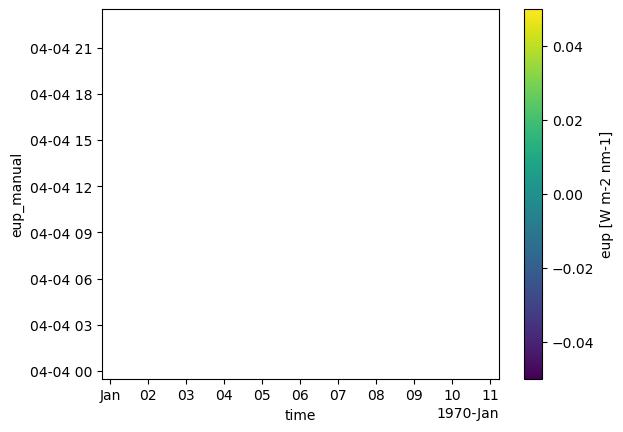

In [9]:
ds_sim['eup'].plot()

### manually calculate the upward flux
ds['eup_manual'] = ds['t_surf']**4 * 5.67e-8  # Stefan-B

ds['eup_manual'].plot(label='Manual Calculation', linestyle='--')


In [ ]:
# Test the fix with a small subset to verify scalar altitude handling
ds_test = ds.isel(time=slice(0, 3))

print("Testing scalar altitude fix with 3 time steps:")
print(f"Input altitudes: {ds_test.altitude.values}")
print(f"Input temperatures: {ds_test.t_surf.values}")

# Run simulation with scalar altitude fix
ds_result_test = ds_test.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=False,  # Don't save to avoid clutter
    surface_temperature_var='t_surf',
)

print(f"\nResult dataset shape: {ds_result_test.dims}")
print(f"Variables: {list(ds_result_test.data_vars.keys())}")
print(f"eup values: {ds_result_test.eup.values}")